In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.io import wavfile

Fs  = 12000   # Hz  f de amostragem
F1  =   750   # Hz
F2  =  1560   # Hz
F3  =   810   # Hz

In [2]:
def make_signal(freqs, Fs, N):
    """Soma de senoides com exatamente N amostras."""
    n = np.arange(N)
    x = sum(np.cos(2*np.pi * f/Fs * n) for f in freqs)
    return x

# F1 + F2, 100 amostras
x_12 = make_signal([F1, F2], Fs, N=100)

In [3]:
def plot_fft(x, Fs, title="FFT"):
    N     = len(x)          
    X     = fft(x)          
    freqs = fftfreq(N, d=1/Fs)

    idx   = freqs >= 0
    f_pos = freqs[idx]
    X_pos = np.abs(X[idx])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title)

    ax1.plot(f_pos, X_pos)
    ax1.set_title("plot()")
    ax1.set_xlabel("Frequência (Hz)")
    ax1.set_ylabel("|X(k)|")
    ax1.grid(True)

    ax2.stem(f_pos, X_pos)
    ax2.set_title("stem()")
    ax2.set_xlabel("Frequência (Hz)")
    ax2.set_ylabel("|X(k)|")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    delta_f = Fs / N
    k1 = round(F1 / delta_f)
    k2 = round(F2 / delta_f)
    print(f"N = {N} amostras")
    print(f"Resolução em frequência : Δf = Fs/N = {Fs}/{N} = {delta_f:.1f} Hz")
    print(f"Índice de F1={F1} Hz    : k = {k1}  →  bin real = {k1*delta_f:.1f} Hz")
    print(f"Índice de F2={F2} Hz    : k = {k2}  →  bin real = {k2*delta_f:.1f} Hz")
    print(f"F2 cai exatamente num bin? {F2 % delta_f == 0}\n")

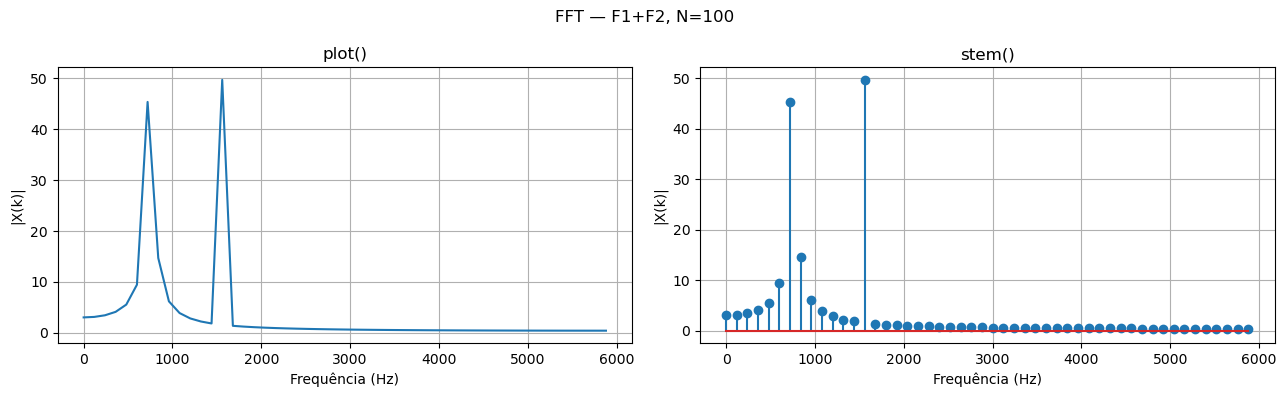

N = 100 amostras
Resolução em frequência : Δf = Fs/N = 12000/100 = 120.0 Hz
Índice de F1=750 Hz    : k = 6  →  bin real = 720.0 Hz
Índice de F2=1560 Hz    : k = 13  →  bin real = 1560.0 Hz
F2 cai exatamente num bin? True



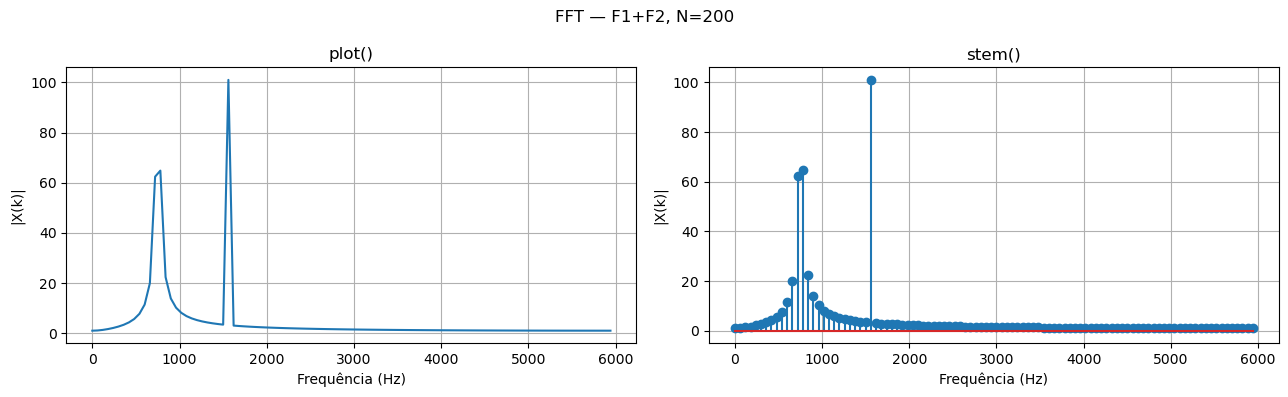

N = 200 amostras
Resolução em frequência : Δf = Fs/N = 12000/200 = 60.0 Hz
Índice de F1=750 Hz    : k = 12  →  bin real = 720.0 Hz
Índice de F2=1560 Hz    : k = 26  →  bin real = 1560.0 Hz
F2 cai exatamente num bin? True



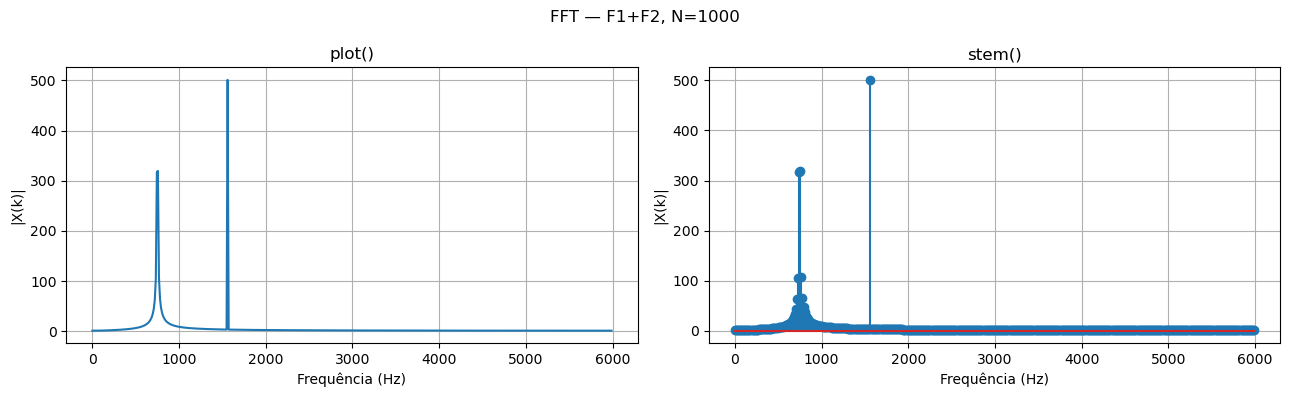

N = 1000 amostras
Resolução em frequência : Δf = Fs/N = 12000/1000 = 12.0 Hz
Índice de F1=750 Hz    : k = 62  →  bin real = 744.0 Hz
Índice de F2=1560 Hz    : k = 130  →  bin real = 1560.0 Hz
F2 cai exatamente num bin? True

N= 100 | Δf=120.0 Hz | F1/Δf=6.2500 | F2/Δf=13.0000 | F3/Δf=6.7500
N= 200 | Δf=60.0 Hz | F1/Δf=12.5000 | F2/Δf=26.0000 | F3/Δf=13.5000
N=1000 | Δf=12.0 Hz | F1/Δf=62.5000 | F2/Δf=130.0000 | F3/Δf=67.5000


In [4]:
plot_fft(make_signal([F1, F2], Fs, N=100), Fs, title="FFT — F1+F2, N=100")
plot_fft(make_signal([F1, F2], Fs, N=200), Fs, title="FFT — F1+F2, N=200")
plot_fft(make_signal([F1, F2], Fs, N=1000), Fs, title="FFT — F1+F2, N=1000")

for N in [100, 200, 1000]:
    delta_f = Fs / N
    print(f"N={N:4d} | Δf={delta_f:.1f} Hz | "
          f"F1/Δf={F1/delta_f:.4f} | "
          f"F2/Δf={F2/delta_f:.4f} | "
          f"F3/Δf={F3/delta_f:.4f}")

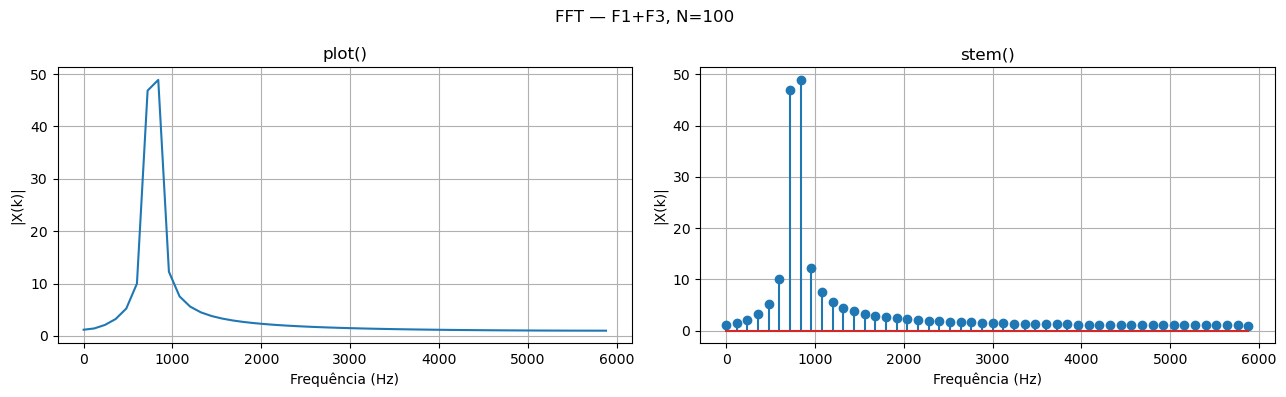

N = 100 amostras
Resolução em frequência : Δf = Fs/N = 12000/100 = 120.0 Hz
Índice de F1=750 Hz    : k = 6  →  bin real = 720.0 Hz
Índice de F2=1560 Hz    : k = 13  →  bin real = 1560.0 Hz
F2 cai exatamente num bin? True



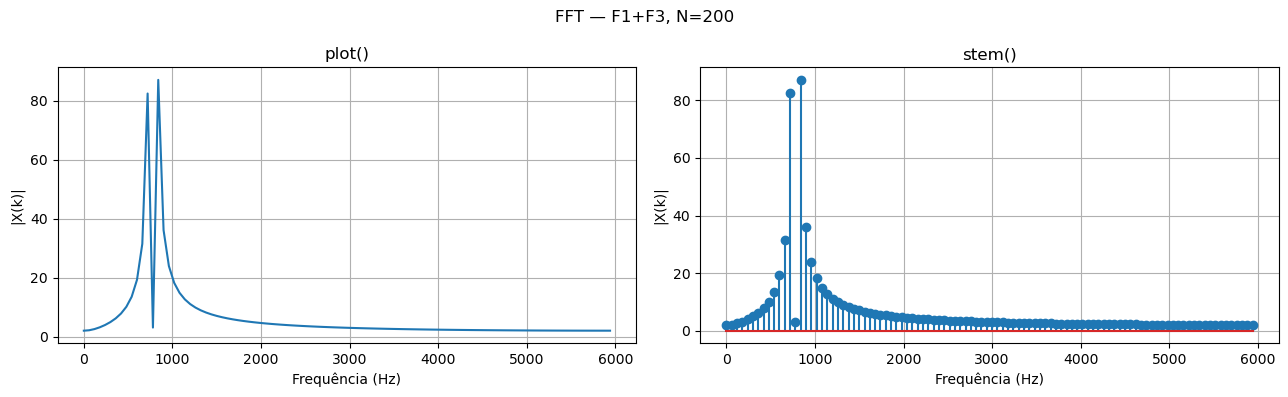

N = 200 amostras
Resolução em frequência : Δf = Fs/N = 12000/200 = 60.0 Hz
Índice de F1=750 Hz    : k = 12  →  bin real = 720.0 Hz
Índice de F2=1560 Hz    : k = 26  →  bin real = 1560.0 Hz
F2 cai exatamente num bin? True



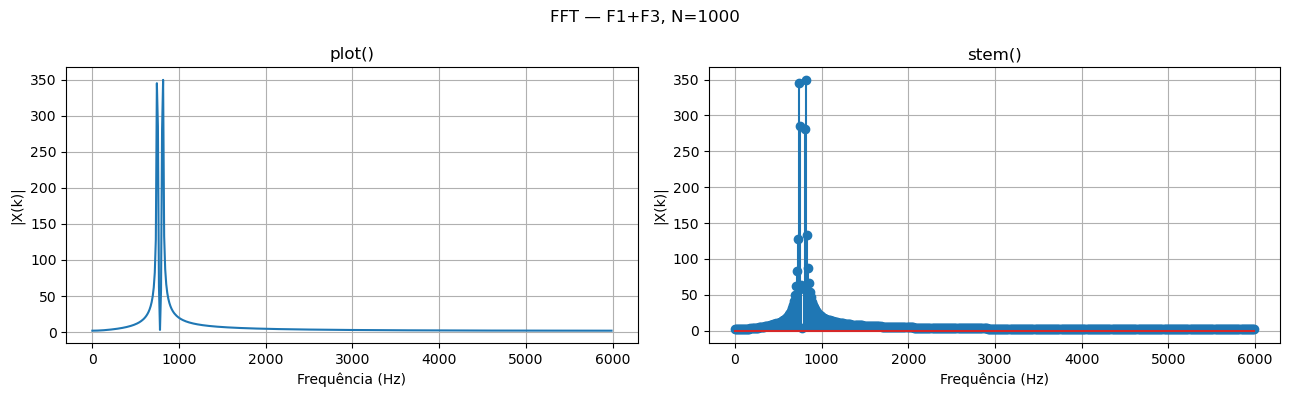

N = 1000 amostras
Resolução em frequência : Δf = Fs/N = 12000/1000 = 12.0 Hz
Índice de F1=750 Hz    : k = 62  →  bin real = 744.0 Hz
Índice de F2=1560 Hz    : k = 130  →  bin real = 1560.0 Hz
F2 cai exatamente num bin? True



In [5]:
plot_fft(make_signal([F1, F3], Fs, N=100), Fs, title="FFT — F1+F3, N=100")
plot_fft(make_signal([F1, F3], Fs, N=200), Fs, title="FFT — F1+F3, N=200")
plot_fft(make_signal([F1, F3], Fs, N=1000), Fs, title="FFT — F1+F3, N=1000")

In [6]:
# ══════════════════════════════════════════════════════════
# Respostas — Itens a até f
# ══════════════════════════════════════════════════════════

print("=" * 60)
print("ITEM a — Resolução em frequência")
print("=" * 60)
for N in [100, 200]:
    delta_f = Fs / N
    print(f"  N={N:4d} → Δf = Fs/N = {Fs}/{N} = {delta_f:.1f} Hz")

print()
print("=" * 60)
print("ITEM b — Índices de frequência de F1 e F2")
print("=" * 60)
for N in [100, 200]:
    delta_f = Fs / N
    k1 = F1 / delta_f
    k2 = F2 / delta_f
    print(f"  N={N}: k(F1={F1}Hz) = {k1:.2f}  |  k(F2={F2}Hz) = {k2:.2f}")

print()
print("=" * 60)
print("ITEM c — Por que não vemos linhas simples?")
print("=" * 60)
print("""
  A DFT assume que o sinal é PERIÓDICO com período exato de N amostras.
  Ao capturar N amostras, aplicamos implicitamente uma JANELA RETANGULAR.
  Se a frequência não coincide com um bin, esses lóbulos se espalham
  pelo espectro inteiro, caracterizando um vazamento espectral.
  O stem() deixa isso mais visível do que o plot().
  No meu caso, a F2 por exemplo coincidiu com um bin, e é mostrado
  no stem() como praticamente um impulso perfeito, enquanto a F1
  se espalha.
""")

print("=" * 60)
print("ITEM d — Qual senoide sofre espalhamento e por quê?")
print("=" * 60)
print(f"  {'N':>6} | {'Δf (Hz)':>8} | {'F1/Δf':>8} | {'F2/Δf':>8} | {'F3/Δf':>8}")
print(f"  {'-'*6}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}")
for N in [100, 200, 1000]:
    df = Fs / N
    print(f"  {N:>6} | {df:>8.1f} | {F1/df:>8.4f} | {F2/df:>8.4f} | {F3/df:>8.4f}")

print("""
  F2 (1560 Hz) cai EXATAMENTE em um bin inteiro para todos os N testados,
  por isso aparece como pulso perfeito sem espalhamento.
  F1 (750 Hz) e F3 (810 Hz) NUNCA caem exatamente em um bin,
  gerando vazamento espectral. O enunciado assumiu que F2 sofreria
  espalhamento, mas na prática ocorreu o contrário.
""")

print("=" * 60)
print("ITEM e — F1+F2 com N=100 vs N=200")
print("=" * 60)
df100, df200 = Fs/100, Fs/200
sep_12 = abs(F2 - F1)
print(f"  Separação F2−F1 = {sep_12} Hz")
print(f"  N=100: Δf={df100:.0f} Hz → razão {sep_12/df100:.1f}×Δf → picos já separados")
print(f"  N=200: Δf={df200:.0f} Hz → razão {sep_12/df200:.1f}×Δf → ainda mais separados")
print("""
  Com N=100 já é possível ver dois picos distintos para F1+F2, pois a
  separação de 810 Hz é muito maior que a resolução de 120 Hz.
  Aumentar N melhora a definição mas não era necessário para separar
  F1 e F2 neste caso.
""")

print("=" * 60)
print("ITEM f — F1+F3 com N=100 vs N=200")
print("=" * 60)
sep_13 = abs(F3 - F1)
print(f"  Separação F3−F1 = {sep_13} Hz")
print(f"  N=100: Δf={df100:.0f} Hz → {sep_13} Hz < {df100:.0f} Hz → componentes NÃO separados")
print(f"  N=200: Δf={df200:.0f} Hz → {sep_13} Hz = {df200:.0f} Hz → componentes separados no LIMITE")
print("""
  F1 e F3 estão separados por apenas 60 Hz. Com N=100, Δf=120 Hz > 60 Hz:
  os lóbulos se sobrepõem e formam um único pico.
  Com N=200, Δf=60 Hz = separação: os picos ficam no limite da
  resolução.
""")

ITEM a — Resolução em frequência
  N= 100 → Δf = Fs/N = 12000/100 = 120.0 Hz
  N= 200 → Δf = Fs/N = 12000/200 = 60.0 Hz

ITEM b — Índices de frequência de F1 e F2
  N=100: k(F1=750Hz) = 6.25  |  k(F2=1560Hz) = 13.00
  N=200: k(F1=750Hz) = 12.50  |  k(F2=1560Hz) = 26.00

ITEM c — Por que não vemos linhas simples?

  A DFT assume que o sinal é PERIÓDICO com período exato de N amostras.
  Ao capturar N amostras, aplicamos implicitamente uma JANELA RETANGULAR.
  Se a frequência não coincide com um bin, esses lóbulos se espalham
  pelo espectro inteiro, caracterizando um vazamento espectral.
  O stem() deixa isso mais visível do que o plot().
  No meu caso, a F2 por exemplo coincidiu com um bin, e é mostrado
  no stem() como praticamente um impulso perfeito, enquanto a F1
  se espalha.

ITEM d — Qual senoide sofre espalhamento e por quê?
       N |  Δf (Hz) |    F1/Δf |    F2/Δf |    F3/Δf
  -------+----------+----------+----------+---------
     100 |    120.0 |   6.2500 |  13.0000 |   6.7

In [7]:
from scipy.signal import get_window

# ── Janelas a comparar ──────────────────────────────────
win_dict = {
    "Retangular" : ("boxcar",   None),
    "Hann"       : ("hann",     None),
    "Hamming"    : ("hamming",  None),
    "Blackman"   : ("blackman", None),
    "Kaiser β=5" : ("kaiser",   5),
    "Kaiser β=14": ("kaiser",   14),
}

def make_window(name, param, N):
    if param is None:
        return get_window(name, N)
    else:
        return get_window((name, param), N)

def compute_spectrum_db(freqs_hz, win_name, win_param, N):
    """Retorna (f_pos, mag_db) para um sinal e uma janela."""
    x_base  = make_signal(freqs_hz, Fs, N)
    w_win   = make_window(win_name, win_param, N)
    X_win   = fft(x_base * w_win)
    freqs   = fftfreq(N, d=1/Fs)
    idx     = freqs >= 0
    mag     = np.abs(X_win[idx])
    mag_db  = 20 * np.log10(mag / mag.max() + 1e-12)
    return freqs[idx], mag_db

def plot_fft_windowed_all(freqs_hz, N=200, title="FFT — todas as janelas"):
    """Todas as janelas sobrepostas num único gráfico."""
    plt.figure(figsize=(12, 5))
    for label, (name, param) in win_dict.items():
        f_pos, mag_db = compute_spectrum_db(freqs_hz, name, param, N)
        plt.plot(f_pos, mag_db, label=label)
    plt.axhline(-3,  color="gray", linestyle=":",  linewidth=0.8, label="-3 dB")
    plt.axhline(-40, color="gray", linestyle="--", linewidth=0.8, label="-40 dB")
    plt.ylim(-80, 5)
    plt.xlim(0, Fs/2)
    plt.grid(True)
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Magnitude (dB, normalizado)")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_fft_windowed_individual(freqs_hz, N=200, title_prefix="FFT"):
    """Um subplot por janela, mesma escala para facilitar comparação."""
    n_wins = len(win_dict)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(title_prefix, fontsize=13)
    axes_flat = axes.flatten()

    for ax, (label, (name, param)) in zip(axes_flat, win_dict.items()):
        f_pos, mag_db = compute_spectrum_db(freqs_hz, name, param, N)
        ax.plot(f_pos, mag_db)
        ax.axhline(-3,  color="gray", linestyle=":",  linewidth=0.8)
        ax.axhline(-40, color="gray", linestyle="--", linewidth=0.8)
        ax.set_ylim(-80, 5)
        ax.set_xlim(0, Fs/2)
        ax.set_title(label)
        ax.set_xlabel("Frequência (Hz)")
        ax.set_ylabel("dB")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

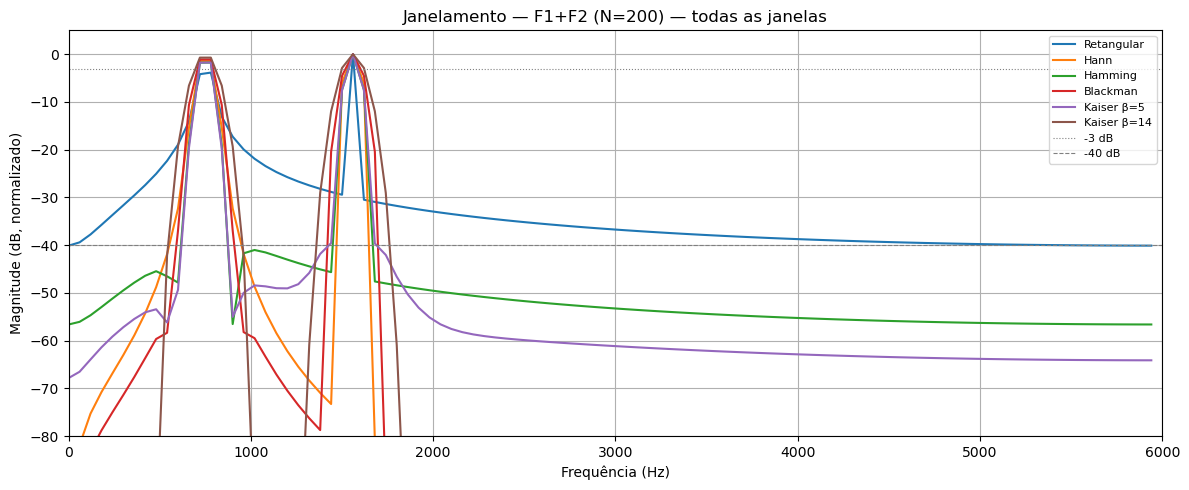

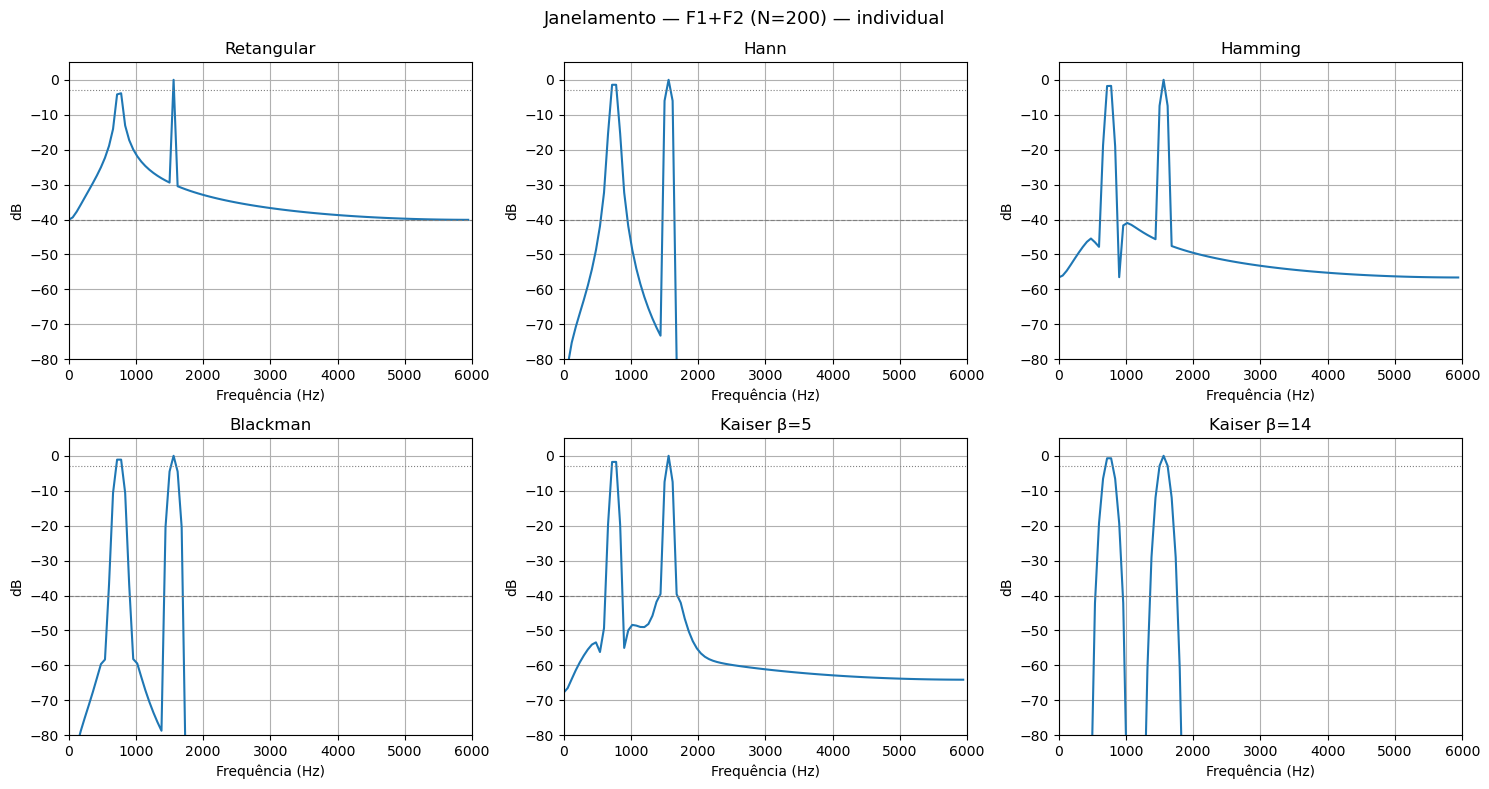

In [8]:
# F1 + F2
plot_fft_windowed_all(        [F1, F2], title="Janelamento — F1+F2 (N=200) — todas as janelas")
plot_fft_windowed_individual( [F1, F2], title_prefix="Janelamento — F1+F2 (N=200) — individual")

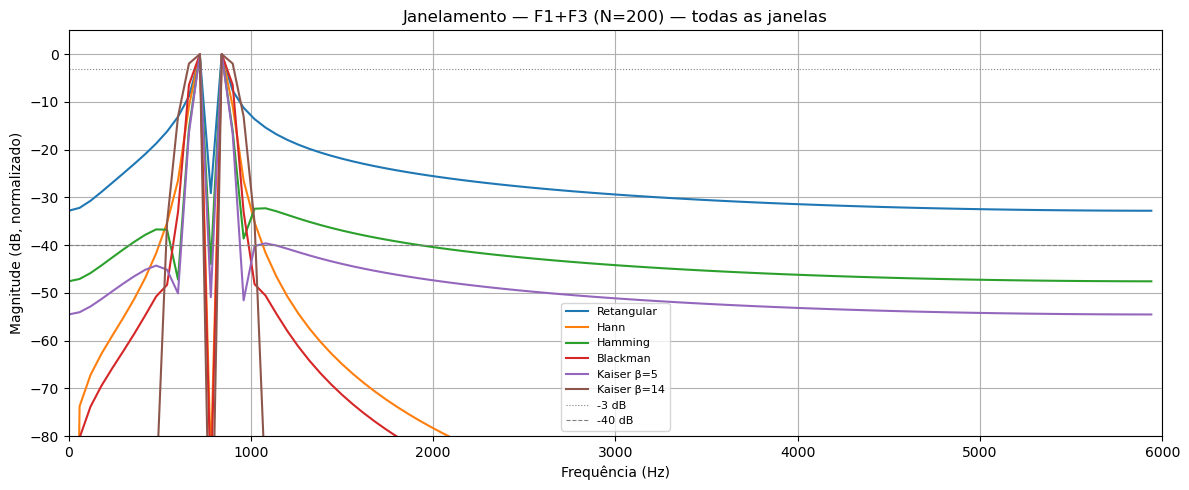

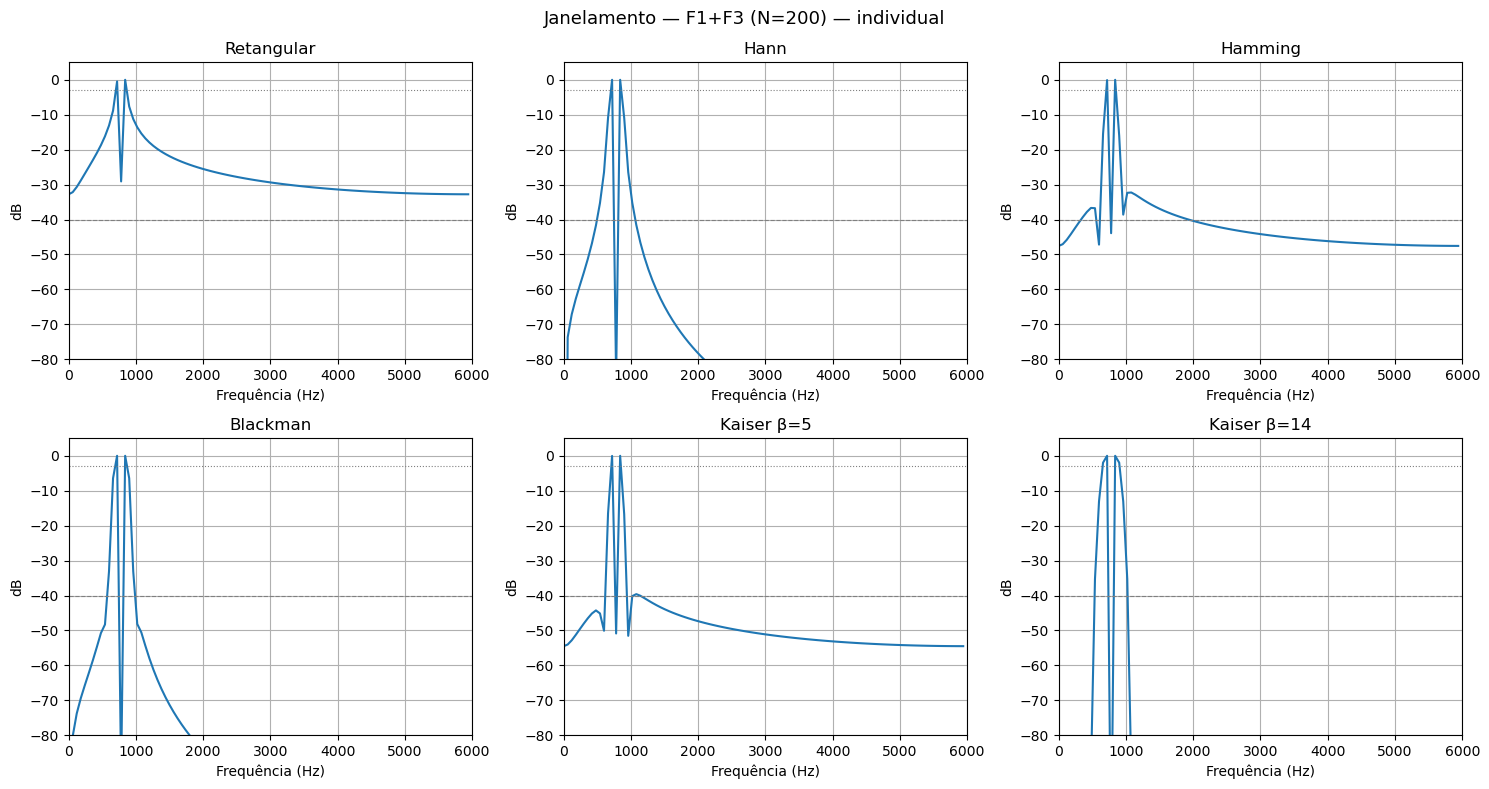

In [9]:
# F1 + F3
plot_fft_windowed_all(        [F1, F3], title="Janelamento — F1+F3 (N=200) — todas as janelas")
plot_fft_windowed_individual( [F1, F3], title_prefix="Janelamento — F1+F3 (N=200) — individual")

In [10]:
print("=" * 60)
print("Retangular (sem janelamento)")
print("=" * 60)
print("""
  Pior caso entre todas as janelas testadas. Os lóbulos laterais
  decaem lentamente (~-32 dB), causando forte espalhamento espectral.
  O pico de F1 é claramente espalhado, enquanto F2 ainda aparece
  nítido por cair exatamente em um bin.
""")

print("=" * 60)
print("Hann")
print("=" * 60)
print("""
  Um dos melhores resultados. Os lóbulos laterais caem abruptamente,
  concentrando a energia nos picos de F1 e F2 (e F1 e F3 no segundo
  caso). O espectro se limita à faixa de 0–1700 Hz, com atenuação
  intensa fora dos picos. F1 ainda apresenta algum espalhamento por
  não cair exatamente em um bin, mas bem menos pronunciado que na
  janela retangular.
""")

print("=" * 60)
print("Hamming")
print("=" * 60)
print("""
  Desempenho intermediário, próximo ao Kaiser β=5. Melhora
  o espalhamento em relação à retangular, com picos mais
  pronunciados, mas os lóbulos laterais não caem abaixo de
  -60 dB (F1+F2) ou -50 dB (F1+F3). Não apresenta a atenuação
  brusca observada em Hann e Blackman.
""")

print("=" * 60)
print("Blackman")
print("=" * 60)
print("""
  Segundo melhor resultado geral. Os gráficos são visualmente
  muito próximos ao Hann, porém com picos ainda mais finos e
  espalhamento ligeiramente reduzido. Assim como Hann e Kaiser β=14,
  a energia se concentra quase que inteiramente na região dos picos.
""")

print("=" * 60)
print("Kaiser β=5")
print("=" * 60)
print("""
  Praticamente idêntico ao Hamming em ambos os casos (F1+F2 e F1+F3).
  O β baixo aproxima a Kaiser de uma janela retangular, oferecendo
  pouca supressão de leakage em troca de maior resolução espectral.
""")

print("=" * 60)
print("Kaiser β=14")
print("=" * 60)
print("""
  Melhor resultado entre todas as janelas testadas. Os lóbulos
  laterais são praticamente inexistentes. Em contrapartida, os picos
  são visivelmente mais largos — semelhantes a uma senoide — refletindo
  o trade-off: ao maximizar a supressão do leakage, sacrifica-se
  a resolução espectral. Para aplicações onde leakage é crítico
  e resolução é secundária, é a melhor escolha.
""")

print("=" * 60)
print("Ranking geral (melhor supressão de leakage)")
print("=" * 60)
print("""
  1º Kaiser β=14   — leakage mínimo, lóbulo principal mais largo
  2º Blackman       — ótimo equilíbrio, picos finos
  3º Hann           — muito próximo ao Blackman
  4º Hamming        — intermediário
  4º Kaiser β=5     — equivalente ao Hamming
  6º Retangular     — sem supressão, referência de pior caso
""")

Retangular (sem janelamento)

  Pior caso entre todas as janelas testadas. Os lóbulos laterais
  decaem lentamente (~-32 dB), causando forte espalhamento espectral.
  O pico de F1 é claramente espalhado, enquanto F2 ainda aparece
  nítido por cair exatamente em um bin.

Hann

  Um dos melhores resultados. Os lóbulos laterais caem abruptamente,
  concentrando a energia nos picos de F1 e F2 (e F1 e F3 no segundo
  caso). O espectro se limita à faixa de 0–1700 Hz, com atenuação
  intensa fora dos picos. F1 ainda apresenta algum espalhamento por
  não cair exatamente em um bin, mas bem menos pronunciado que na
  janela retangular.

Hamming

  Desempenho intermediário, próximo ao Kaiser β=5. Melhora
  o espalhamento em relação à retangular, com picos mais
  pronunciados, mas os lóbulos laterais não caem abaixo de
  -60 dB (F1+F2) ou -50 dB (F1+F3). Não apresenta a atenuação
  brusca observada em Hann e Blackman.

Blackman

  Segundo melhor resultado geral. Os gráficos são visualmente
  muit

fs piano   = 11025
fs trumpet = 11025


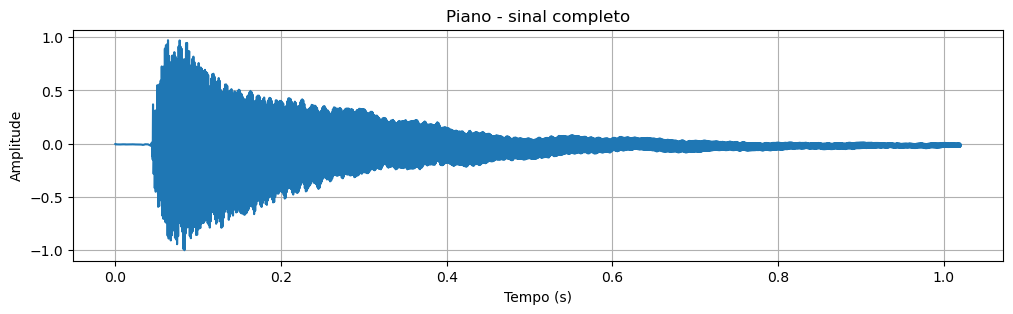

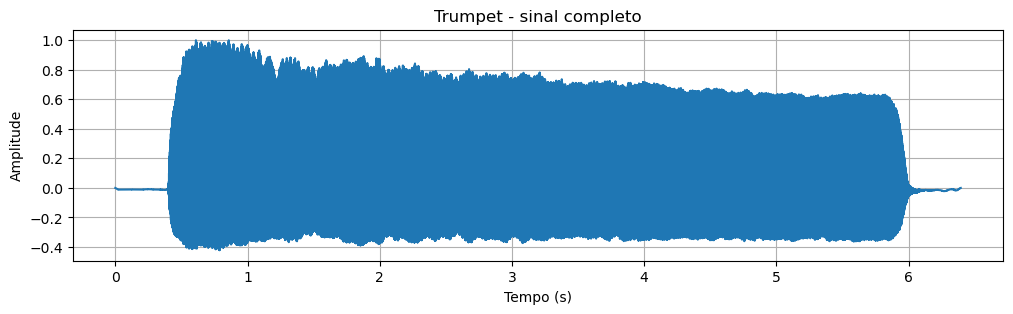

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
from scipy.signal import get_window, find_peaks

def carregar_audio(caminho):
    fs, x = wavfile.read(caminho)

    # Se o áudio for estéreo, converte para mono
    if x.ndim > 1:
        x = x.mean(axis=1)

    # Converte para float e normaliza
    x = x.astype(np.float64)
    x = x / np.max(np.abs(x))

    return fs, x

def plotar_sinal(x, fs, titulo="Sinal no tempo"):
    t = np.arange(len(x)) / fs
    plt.figure(figsize=(12, 3))
    plt.plot(t, x)
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.title(titulo)
    plt.grid(True)
    plt.show()

fs_piano, x_piano = carregar_audio("piano-G5.wav")
fs_trumpet, x_trumpet = carregar_audio("trumpet-G5.wav")

print("fs piano   =", fs_piano)
print("fs trumpet =", fs_trumpet)

plotar_sinal(x_piano, fs_piano, "Piano - sinal completo")
plotar_sinal(x_trumpet, fs_trumpet, "Trumpet - sinal completo")

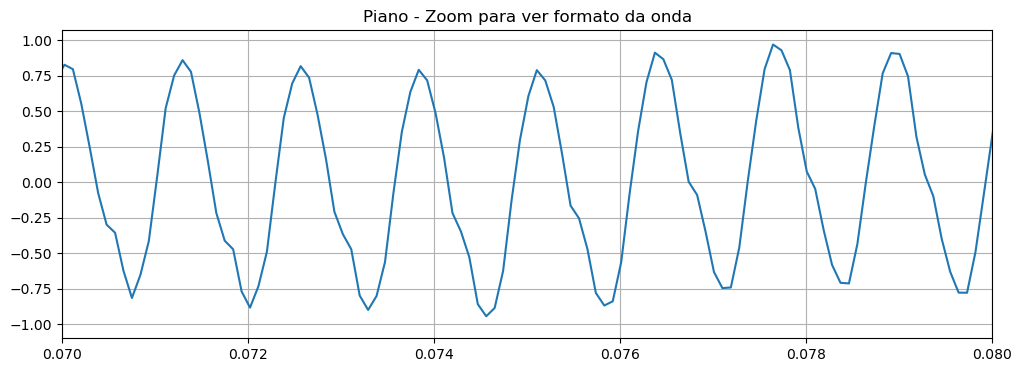

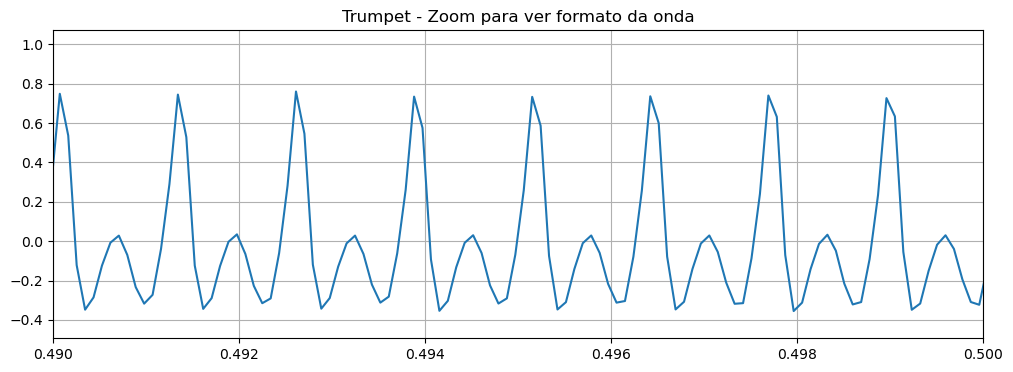

In [12]:
plt.figure(figsize=(12,4))
plt.plot(np.arange(len(x_piano))/fs_piano, x_piano)
plt.xlim(0.07, 0.08)
plt.grid()
plt.title("Piano - Zoom para ver formato da onda")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(np.arange(len(x_trumpet))/fs_trumpet, x_trumpet)
plt.xlim(0.49, 0.5)
plt.grid()
plt.title("Trumpet - Zoom para ver formato da onda")
plt.show()

In [13]:
inicio_piano = 0.15
fim_piano    = 0.55

inicio_trumpet = 1.0
fim_trumpet    = 1.4

trecho_piano = x_piano[
    int(inicio_piano*fs_piano):
    int(fim_piano*fs_piano)
]

trecho_trumpet = x_trumpet[
    int(inicio_trumpet*fs_trumpet):
    int(fim_trumpet*fs_trumpet)
]

print("Amostras piano:", len(trecho_piano))
print("Amostras trumpet:", len(trecho_trumpet))

Amostras piano: 4410
Amostras trumpet: 4409


In [14]:
def plotar_fft_audio(x, fs, N, titulo):

    janela = np.hanning(N)

    x_fft = x[:N] * janela

    X = fft(x_fft)

    f = fftfreq(N, 1/fs)

    idx = f >= 0

    f = f[idx]
    X = X[idx]

    mag = np.abs(X)

    plt.figure(figsize=(12,4))
    plt.plot(f, mag)

    plt.title(f"{titulo} (N={N})")
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("|X(k)|")
    plt.grid(True)

    plt.xlim(0, 5000)
    
    plt.show()

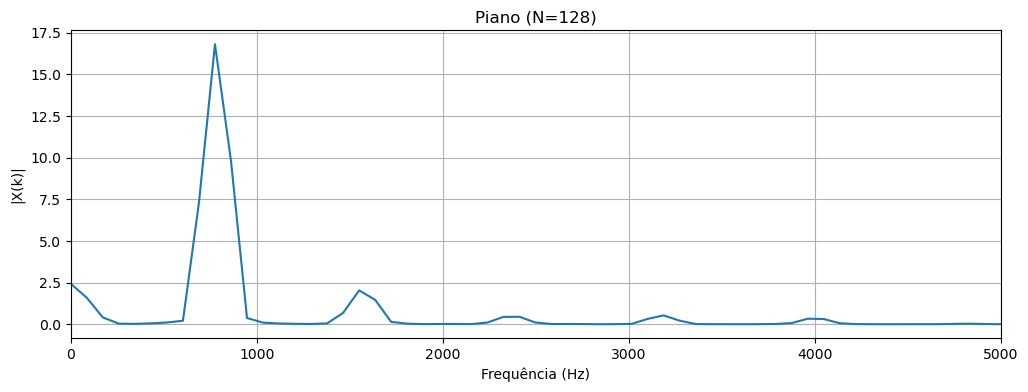

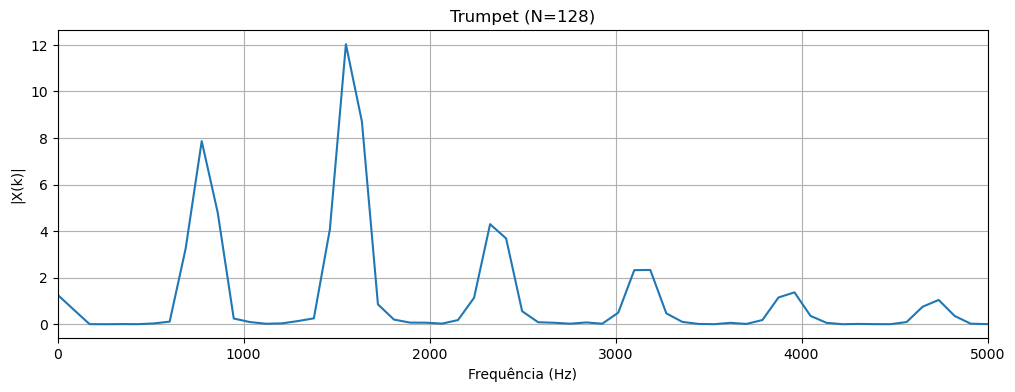

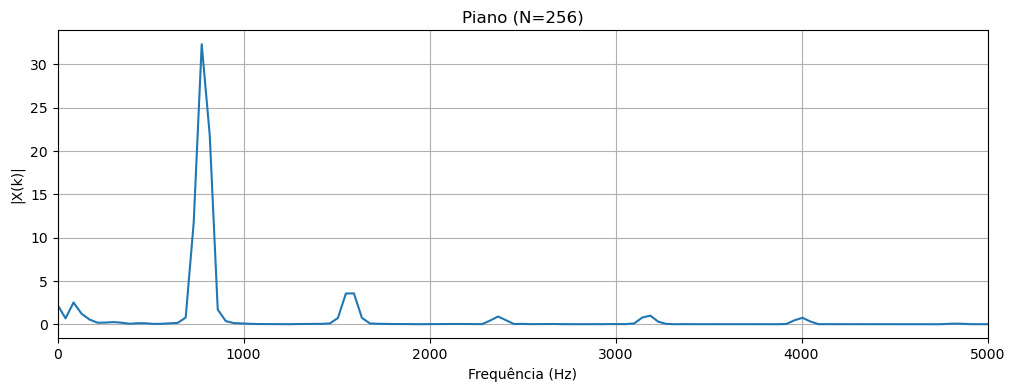

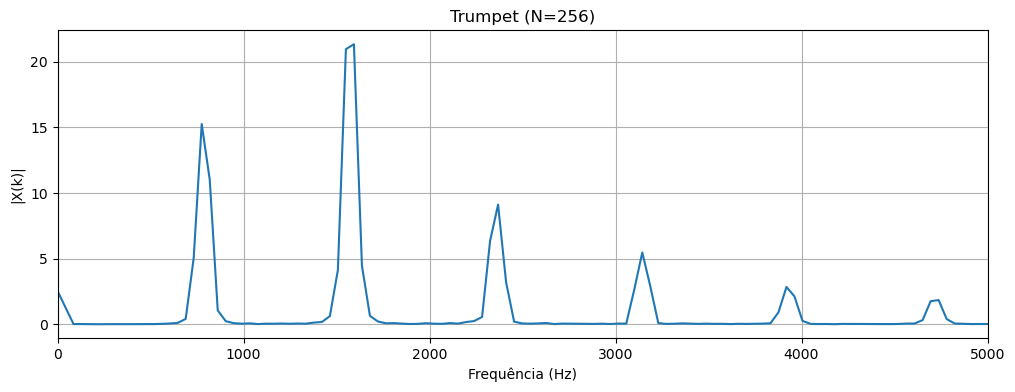

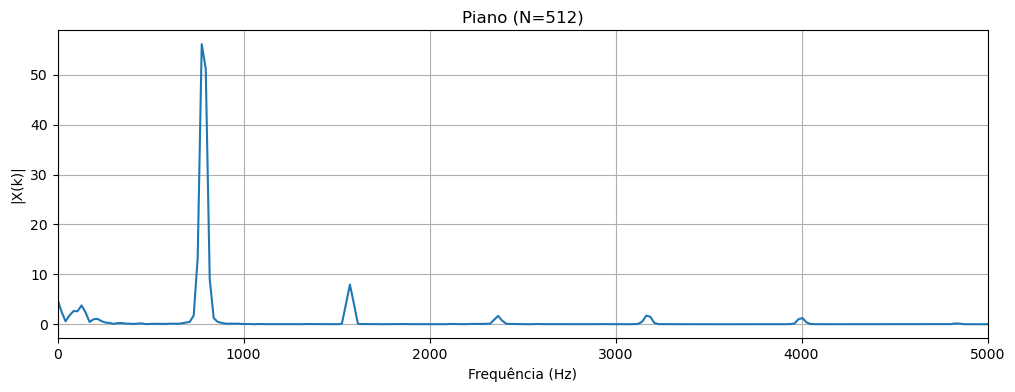

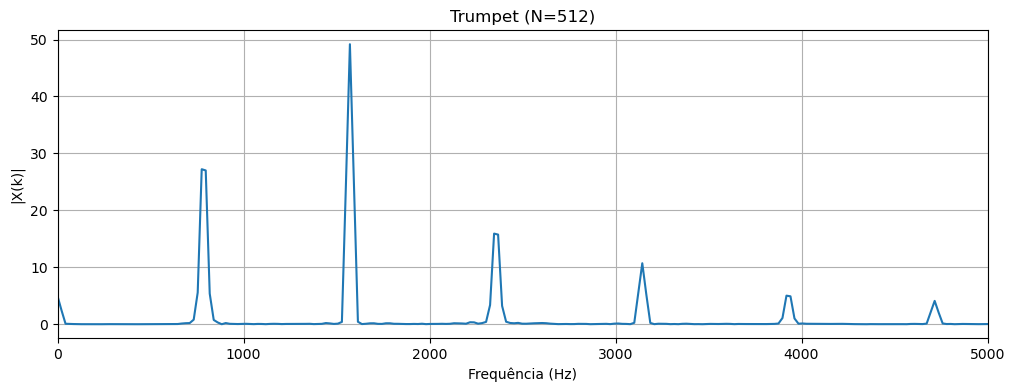

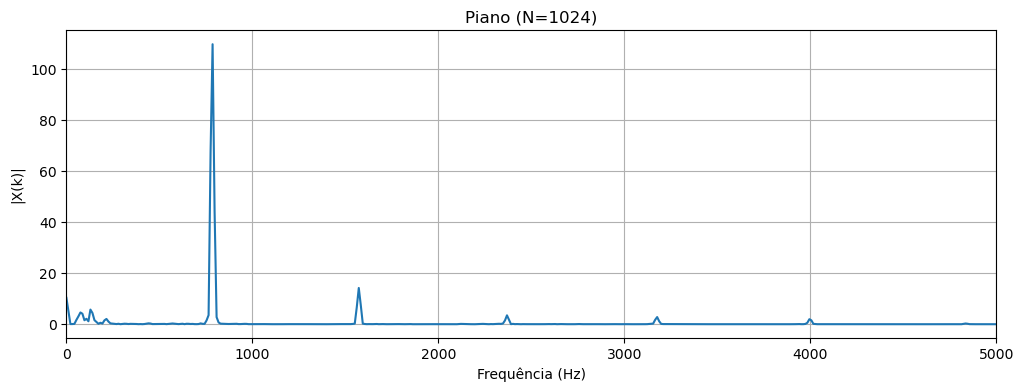

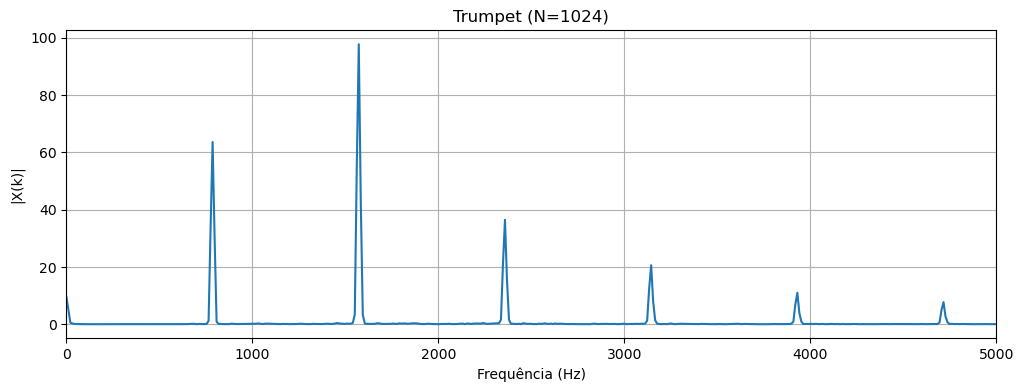

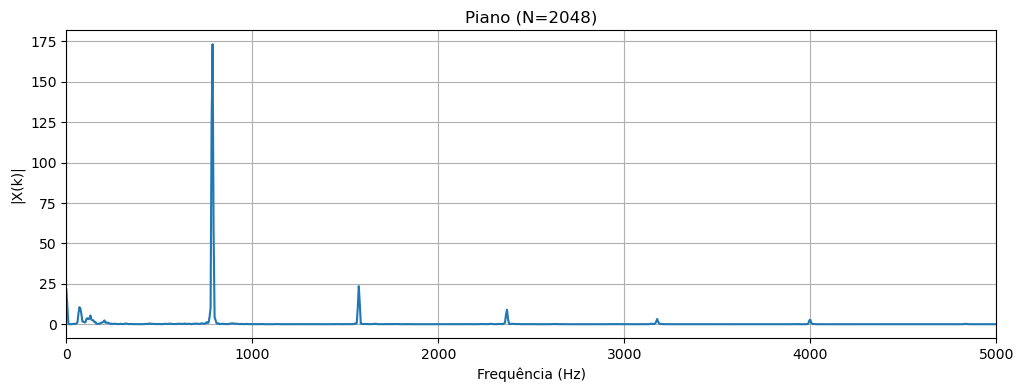

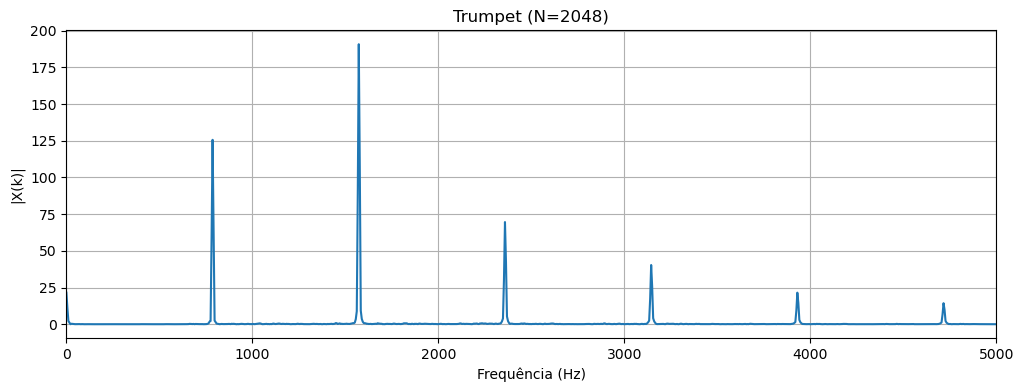

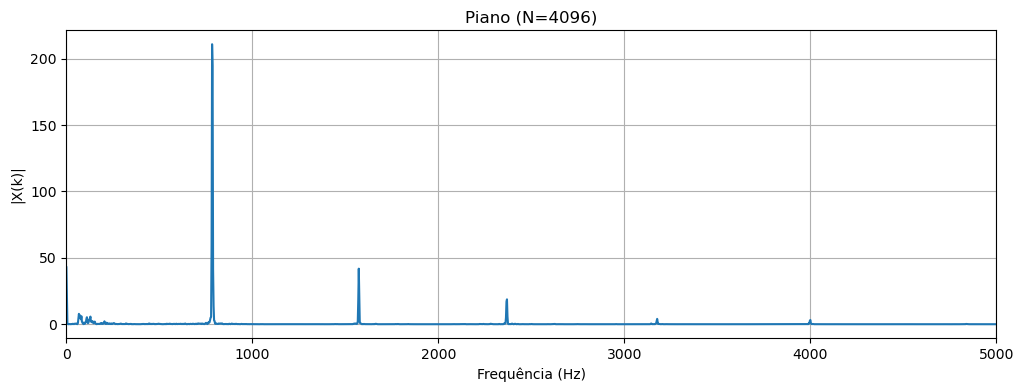

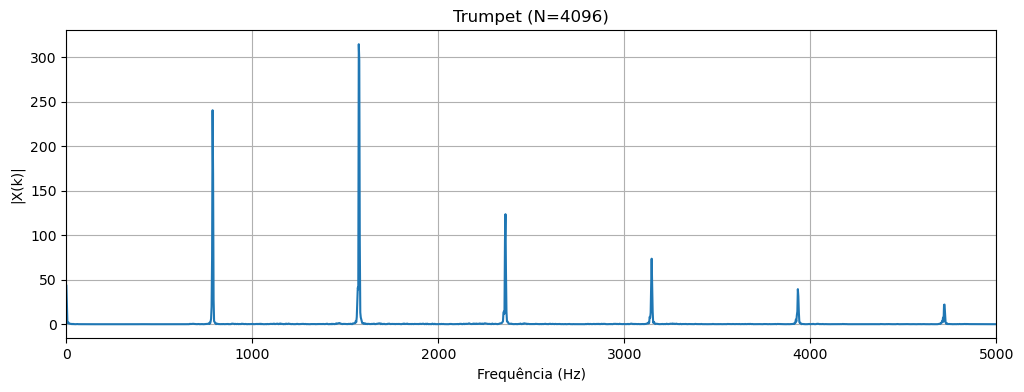

In [15]:
for N in [128, 256, 512, 1024, 2048, 4096]:

    plotar_fft_audio(
        trecho_piano,
        fs_piano,
        N,
        "Piano"
    )

    plotar_fft_audio(
        trecho_trumpet,
        fs_trumpet,
        N,
        "Trumpet"
    )

In [16]:
print("=" * 60)
print("ANÁLISE DOS SINAIS DE ÁUDIO")
print("=" * 60)
print("""
  Foram analisados os sinais de áudio do piano e do trompete
  executando a mesma nota musical (G5). Para evitar influência
  do silêncio inicial e do ataque dos instrumentos, foi selecionado
  um trecho representativo da região mais estável de cada sinal.

  Foram calculadas FFTs utilizando:

      N = 128, 256, 512, 1024, 2048 e 4096

  Observou-se que mesmo para N=128 já foi possível identificar
  visualmente a frequência fundamental e os principais harmônicos.
  O aumento de N melhora a resolução em frequência e torna os
  picos mais bem definidos, porém sem alterar significativamente
  a interpretação do espectro.
""")

print("=" * 60)
print("RESULTADOS - PIANO")
print("=" * 60)
print("""
  O espectro do piano apresentou um pico dominante na frequência
  fundamental (~784 Hz), correspondente à nota G5.

  Os harmônicos apareceram aproximadamente em múltiplos inteiros
  dessa frequência (2f0, 3f0, 4f0, ...), porém com amplitudes
  significativamente menores.

  Isso indica que a maior parte da energia do sinal está concentrada
  na frequência fundamental, fazendo com que a forma de onda se
  aproxime de uma senoide com pequenas deformações.

  O rápido decaimento das amplitudes harmônicas explica o timbre
  mais suave e menos brilhante observado no piano.
""")

print("=" * 60)
print("RESULTADOS - TROMPETE")
print("=" * 60)
print("""
  O espectro do trompete apresentou comportamento bastante
  diferente do piano.

  Embora a frequência fundamental (~784 Hz) esteja presente,
  o segundo harmônico (~1568 Hz) apresentou amplitude superior
  à da própria fundamental.

  Esse resultado é esperado para instrumentos de metal, que
  normalmente apresentam maior conteúdo harmônico e formas de
  onda significativamente mais distantes de uma senoide.

  Os harmônicos de ordem superior também permaneceram com
  amplitudes relevantes, caracterizando um timbre mais rico
  e brilhante.
""")

print("=" * 60)
print("FREQUÊNCIA FUNDAMENTAL E HARMÔNICOS")
print("=" * 60)
print("""
  A frequência fundamental não é necessariamente o pico de maior
  amplitude do espectro.

  Ela é identificada como a frequência base da qual os demais
  componentes são múltiplos inteiros.

  No caso do trompete, apesar do segundo harmônico possuir maior
  amplitude que a fundamental, as demais componentes aparecem em
  frequências aproximadamente iguais a:

      f0, 2f0, 3f0, 4f0, ...

  Portanto, a frequência fundamental continua sendo a menor
  frequência da série harmônica, enquanto as demais componentes
  correspondem aos seus harmônicos.
""")

print("=" * 60)
print("CONCLUSÃO")
print("=" * 60)
print("""
  Ambos os instrumentos executam a mesma nota musical e,
  consequentemente, possuem a mesma frequência fundamental.

  Entretanto, a distribuição de energia entre os harmônicos
  é bastante diferente, produzindo timbres distintos.

  O piano concentra energia principalmente na frequência
  fundamental, enquanto o trompete apresenta forte conteúdo
  harmônico, inclusive com o segundo harmônico superando a
  amplitude da fundamental.

  O menor valor de N que permitiu identificar adequadamente a
  frequência fundamental e os principais harmônicos foi N=128.
  Valores maiores aumentam a resolução espectral e facilitam a
  visualização dos picos, mas não alteram as conclusões da análise.
""")

ANÁLISE DOS SINAIS DE ÁUDIO

  Foram analisados os sinais de áudio do piano e do trompete
  executando a mesma nota musical (G5). Para evitar influência
  do silêncio inicial e do ataque dos instrumentos, foi selecionado
  um trecho representativo da região mais estável de cada sinal.

  Foram calculadas FFTs utilizando:

      N = 128, 256, 512, 1024, 2048 e 4096

  Observou-se que mesmo para N=128 já foi possível identificar
  visualmente a frequência fundamental e os principais harmônicos.
  O aumento de N melhora a resolução em frequência e torna os
  picos mais bem definidos, porém sem alterar significativamente
  a interpretação do espectro.

RESULTADOS - PIANO

  O espectro do piano apresentou um pico dominante na frequência
  fundamental (~784 Hz), correspondente à nota G5.

  Os harmônicos apareceram aproximadamente em múltiplos inteiros
  dessa frequência (2f0, 3f0, 4f0, ...), porém com amplitudes
  significativamente menores.

  Isso indica que a maior parte da energia do si